# ODD + OOD Detection for Safe Autonomy
**Camera-based safety gate for autonomous driving**

- **Input**: Front camera frame
- **Output**: "Trust / Abstain" gate decision
- **ODD**: Daytime + Clear weather + Urban/Highway
- **OOD buckets**: Night, Rain, Fog/Snow

**Members**: Tharun Reddy Challabotla, HariChandana Srikurmum, Srija

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm
!pip install -q kagglehub

In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Dataset Download (BDD100K Weather Classification via kagglehub)

Uses `kagglehub` — no `kaggle.json` file upload needed.  
On first run it will ask you to authenticate via browser (one-time). The dataset is cached in `~/.cache/kagglehub` and reused on subsequent runs.

In [3]:
import kagglehub

# Download latest version — authenticates via browser on first run
# Credentials are cached in ~/.cache/kagglehub after the first login
kaggle_path = kagglehub.dataset_download('marquis03/bdd100k-weather-classification')
print('Path to dataset files:', kaggle_path)

from pathlib import Path
BDD_RAW = Path(kaggle_path)

# kagglehub sometimes nests files under a version subfolder;
# find the directory that actually contains train/ and val/ folders
def find_dataset_root(base: Path) -> Path:
    if (base / 'train').exists() or (base / 'val').exists():
        return base
    for child in sorted(base.rglob('train')):
        if child.is_dir():
            return child.parent
    return base
BDD_RAW = find_dataset_root(BDD_RAW)
print(f'Dataset root: {BDD_RAW}')

# Show splits and weather folders
for split in ['train', 'val']:
    split_dir = BDD_RAW / split
    if split_dir.exists():
        folders = [f.name for f in sorted(split_dir.iterdir()) if f.is_dir()]
        print(f'  {split}: {folders}')

Using Colab cache for faster access to the 'bdd100k-weather-classification' dataset.
Path to dataset files: /kaggle/input/bdd100k-weather-classification
Dataset root: /kaggle/input/bdd100k-weather-classification
  train: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']
  val: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']


In [4]:
# Verify dataset structure
DATA_ROOT = BDD_RAW  # alias used throughout the notebook

total_imgs = sum(1 for p in BDD_RAW.rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png'})
print(f'Total images found: {total_imgs:,}')

Total images found: 99,863


In [5]:
# --- CELL 1: DATASET MAPPING & PREPROCESSING ---

# Define the binary mapping based on your previous ID vs OOD definitions
# 0 = In-Distribution (Safe/Clear)
# 1 = Out-of-Distribution (Adverse Weather)
WEATHER_MAPPING = {
    'clear': 0,
    'partly cloudy': 0,
    'overcast': 0,
    'rainy': 1,
    'snowy': 1,
    'foggy': 1
}

class BDDWeatherBinaryDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.samples = []

        # Iterate through weather folders
        for weather_folder in self.root_dir.iterdir():
            if weather_folder.is_dir() and weather_folder.name.lower() in WEATHER_MAPPING:
                label = WEATHER_MAPPING[weather_folder.name.lower()]
                for img_path in weather_folder.glob('*.jpg'):
                    self.samples.append((str(img_path), label))

        print(f"Loaded {split} split: {len(self.samples)} images.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Standard ImageNet Transforms for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = BDDWeatherBinaryDataset(DATA_ROOT, split='train', transform=transform)
val_dataset = BDDWeatherBinaryDataset(DATA_ROOT, split='val', transform=transform)

# Standard Loaders for Feature Extraction (batch size can be high since no gradients are computed)
extract_train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=2)
extract_val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

Loaded train split: 61744 images.
Loaded val split: 8843 images.


In [6]:
# --- CELL 2: EXTRACT AND CACHE BACKBONE FEATURES ---

# Load Pretrained ResNet-50 and strip the final classification head
backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
backbone.fc = nn.Identity() # Replaces the final layer with a pass-through
backbone = backbone.to(DEVICE)
backbone.eval() # Freeze it!

def extract_and_save_features(loader, save_prefix):
    features_list = []
    labels_list = []

    print(f"Extracting features for {save_prefix}...")
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Processing {save_prefix}"):
            images = images.to(DEVICE)
            # ResNet output shape: [Batch, 2048]
            feats = backbone(images)

            features_list.append(feats.cpu())
            labels_list.append(labels.cpu())

    # Concatenate all batches
    all_features = torch.cat(features_list, dim=0)
    all_labels = torch.cat(labels_list, dim=0)

    # Save to disk as PyTorch tensors
    torch.save(all_features, f"{save_prefix}_features.pt")
    torch.save(all_labels, f"{save_prefix}_labels.pt")
    print(f"Saved {save_prefix}: Features {all_features.shape}, Labels {all_labels.shape}")

# Run extraction (only needs to be done once!)
extract_and_save_features(extract_train_loader, "train")
extract_and_save_features(extract_val_loader, "val")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 241MB/s]


Extracting features for train...


Processing train:   0%|          | 0/483 [00:00<?, ?it/s]

Saved train: Features torch.Size([61744, 2048]), Labels torch.Size([61744])
Extracting features for val...


Processing val:   0%|          | 0/70 [00:00<?, ?it/s]

Saved val: Features torch.Size([8843, 2048]), Labels torch.Size([8843])


In [7]:
# --- CELL 3: LOAD CACHED FEATURES ---
from torch.utils.data import TensorDataset

# Load cached tensors
train_features = torch.load("train_features.pt")
train_labels = torch.load("train_labels.pt")

val_features = torch.load("val_features.pt")
val_labels = torch.load("val_labels.pt")

# Create lightning-fast TensorDatasets
vector_train_dataset = TensorDataset(train_features, train_labels)
vector_val_dataset = TensorDataset(val_features, val_labels)

# We can use smaller batch sizes now for actual training
train_loader = DataLoader(vector_train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(vector_val_dataset, batch_size=64, shuffle=False)

In [8]:
# --- CELL 4: DEEP SVDD ARCHITECTURE ---

# Deep SVDD should be trained only on in-distribution features.
train_id_mask = (train_labels == 0)
id_train_features = train_features[train_id_mask]

print('ID-only training features:', id_train_features.shape)
print('Validation features      :', val_features.shape)

class DeepSVDDNet(nn.Module):
    def __init__(self, input_dim=2048, rep_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, rep_dim)
        )

    def forward(self, x):
        return self.net(x)


def init_center_c(model, loader, eps=0.1):
    model.eval()
    reps = []
    with torch.no_grad():
        for (features,) in loader:
            features = features.to(DEVICE)
            reps.append(model(features))

    c = torch.cat(reps, dim=0).mean(dim=0)

    # Avoid trivial near-zero coordinates in the center.
    c[(torch.abs(c) < eps) & (c < 0)] = -eps
    c[(torch.abs(c) < eps) & (c >= 0)] = eps
    return c.detach()


def svdd_distance(representations, center):
    return torch.sum((representations - center) ** 2, dim=1)


svdd_model = DeepSVDDNet(input_dim=train_features.shape[1], rep_dim=128).to(DEVICE)
optimizer = torch.optim.Adam(svdd_model.parameters(), lr=1e-4, weight_decay=1e-6)

id_train_dataset = TensorDataset(id_train_features)
id_train_loader = DataLoader(id_train_dataset, batch_size=64, shuffle=True)

print('Deep SVDD model initialized.')



ID-only training features: torch.Size([50995, 2048])
Validation features      : torch.Size([8843, 2048])
Deep SVDD model initialized.


In [9]:
# --- CELL 5: TRAIN DEEP SVDD ON ID-ONLY DATA ---

EPOCHS = 20

center_loader = DataLoader(id_train_dataset, batch_size=256, shuffle=False)
center_c = init_center_c(svdd_model, center_loader)
print('Initialized SVDD center with shape:', center_c.shape)

print('Starting Deep SVDD training...')
for epoch in range(EPOCHS):
    svdd_model.train()
    total_loss = 0.0

    for (features,) in id_train_loader:
        features = features.to(DEVICE)

        optimizer.zero_grad()
        reps = svdd_model(features)
        dist = svdd_distance(reps, center_c)
        loss = dist.mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / max(len(id_train_loader), 1)
    print(f'Epoch {epoch + 1:02d}/{EPOCHS} | Avg SVDD Loss: {avg_loss:.6f}')



Initialized SVDD center with shape: torch.Size([128])
Starting Deep SVDD training...
Epoch 01/20 | Avg SVDD Loss: 0.015647
Epoch 02/20 | Avg SVDD Loss: 0.002165
Epoch 03/20 | Avg SVDD Loss: 0.000440
Epoch 04/20 | Avg SVDD Loss: 0.000049
Epoch 05/20 | Avg SVDD Loss: 0.000011
Epoch 06/20 | Avg SVDD Loss: 0.000004
Epoch 07/20 | Avg SVDD Loss: 0.000002
Epoch 08/20 | Avg SVDD Loss: 0.000001
Epoch 09/20 | Avg SVDD Loss: 0.000000
Epoch 10/20 | Avg SVDD Loss: 0.000000
Epoch 11/20 | Avg SVDD Loss: 0.000000
Epoch 12/20 | Avg SVDD Loss: 0.000000
Epoch 13/20 | Avg SVDD Loss: 0.000000
Epoch 14/20 | Avg SVDD Loss: 0.000000
Epoch 15/20 | Avg SVDD Loss: 0.000000
Epoch 16/20 | Avg SVDD Loss: 0.000000
Epoch 17/20 | Avg SVDD Loss: 0.000000
Epoch 18/20 | Avg SVDD Loss: 0.000000
Epoch 19/20 | Avg SVDD Loss: 0.000000
Epoch 20/20 | Avg SVDD Loss: 0.000000


Evaluating Deep SVDD on validation data...
Deep SVDD AUROC  : 0.5841
Deep SVDD AUPR   : 0.2454
Deep SVDD FPR95  : 0.9332

Tuned Deep SVDD threshold:
{'threshold': 1.3599663921202815e-09, 'false_safe_rate': 0.049342105263157895, 'coverage': 0.06253533868596631}
ID acceptance rate : 0.0653
OOD rejection rate : 0.9507


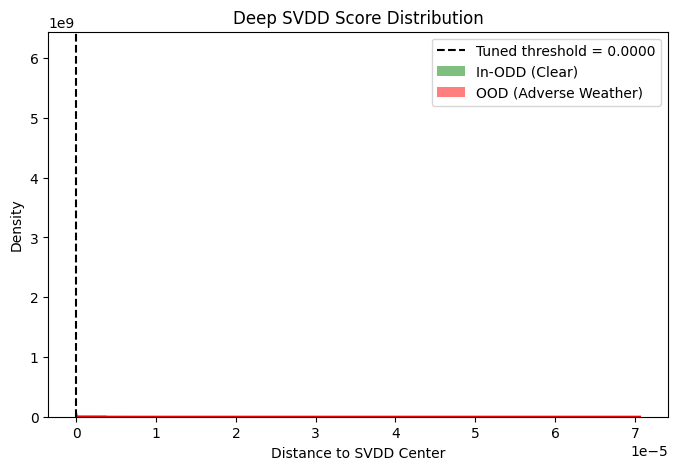

In [10]:
# --- CELL 6: EVALUATION, OOD METRICS, AND THRESHOLD TUNING ---

def compute_svdd_scores(model, features, batch_size=256):
    model.eval()
    loader = DataLoader(TensorDataset(features), batch_size=batch_size, shuffle=False)
    all_scores = []

    with torch.no_grad():
        for (batch_features,) in loader:
            batch_features = batch_features.to(DEVICE)
            reps = model(batch_features)
            scores = svdd_distance(reps, center_c)
            all_scores.append(scores.cpu())

    return torch.cat(all_scores).numpy()


def fpr_at_95_tpr(y_true, score):
    fpr, tpr, _ = roc_curve(y_true, score)
    valid = np.where(tpr >= 0.95)[0]
    return float(fpr[valid[0]]) if len(valid) else 1.0


def tune_threshold(ood_labels, ood_score, false_safe_budget=0.05):
    thresholds = np.quantile(ood_score, np.linspace(0.01, 0.99, 300))
    best = None

    for threshold in thresholds:
        trust_mask = ood_score < threshold
        false_safe_rate = float(np.mean(trust_mask[ood_labels == 1])) if np.any(ood_labels == 1) else 0.0
        coverage = float(np.mean(trust_mask))

        if false_safe_rate <= false_safe_budget:
            if best is None or coverage > best['coverage']:
                best = {
                    'threshold': float(threshold),
                    'false_safe_rate': false_safe_rate,
                    'coverage': coverage,
                }

    if best is None:
        best = {
            'threshold': float(np.max(ood_score)),
            'false_safe_rate': 0.0,
            'coverage': 0.0,
        }

    return best


print('Evaluating Deep SVDD on validation data...')
val_svdd_scores = compute_svdd_scores(svdd_model, val_features)
val_labels_arr = val_labels.numpy()

print(f'Deep SVDD AUROC  : {roc_auc_score(val_labels_arr, val_svdd_scores):.4f}')
print(f'Deep SVDD AUPR   : {average_precision_score(val_labels_arr, val_svdd_scores):.4f}')
print(f'Deep SVDD FPR95  : {fpr_at_95_tpr(val_labels_arr, val_svdd_scores):.4f}')

best_gate = tune_threshold(val_labels_arr, val_svdd_scores, false_safe_budget=0.05)
SVDD_THRESHOLD = best_gate['threshold']
print('\nTuned Deep SVDD threshold:')
print(best_gate)

trust_mask = val_svdd_scores < SVDD_THRESHOLD
rejection_rate_ood = float(np.mean(~trust_mask[val_labels_arr == 1])) if np.any(val_labels_arr == 1) else 0.0
acceptance_rate_id = float(np.mean(trust_mask[val_labels_arr == 0])) if np.any(val_labels_arr == 0) else 0.0
print(f'ID acceptance rate : {acceptance_rate_id:.4f}')
print(f'OOD rejection rate : {rejection_rate_ood:.4f}')

plt.figure(figsize=(8, 5))
sns.histplot(val_svdd_scores[val_labels_arr == 0], color='green', label='In-ODD (Clear)', kde=True, stat='density')
sns.histplot(val_svdd_scores[val_labels_arr == 1], color='red', label='OOD (Adverse Weather)', kde=True, stat='density')
plt.axvline(SVDD_THRESHOLD, color='black', linestyle='--', label=f'Tuned threshold = {SVDD_THRESHOLD:.4f}')
plt.title('Deep SVDD Score Distribution')
plt.xlabel('Distance to SVDD Center')
plt.ylabel('Density')
plt.legend()
plt.show()



In [11]:
# --- CELL 7: DEPLOYMENT-STYLE SAFETY GATE ---

def runtime_safety_gate(features, threshold=SVDD_THRESHOLD):
    scores = compute_svdd_scores(svdd_model, features)
    decisions = []

    for score in scores:
        decision = 'ABSTAIN' if score >= threshold else 'TRUST'
        decisions.append({
            'decision': decision,
            'svdd_score': float(score),
        })

    return decisions


print('Deploying Deep SVDD safety gate...\n')
print('=' * 80)

sample_features = val_features[:10]
sample_labels = val_labels[:10].numpy()
gate_results = runtime_safety_gate(sample_features)

for i, result in enumerate(gate_results, start=1):
    actual = 'In-ODD' if sample_labels[i - 1] == 0 else 'OOD'
    print(f'Frame {i} [Ground Truth: {actual}]')
    print(f"  -> Decision    : {result['decision']}")
    print(f"  -> SVDD Score  : {result['svdd_score']:.4f}")
    print('-' * 80)



Deploying Deep SVDD safety gate...

Frame 1 [Ground Truth: In-ODD]
  -> Decision    : ABSTAIN
  -> SVDD Score  : 0.0000
--------------------------------------------------------------------------------
Frame 2 [Ground Truth: In-ODD]
  -> Decision    : ABSTAIN
  -> SVDD Score  : 0.0000
--------------------------------------------------------------------------------
Frame 3 [Ground Truth: In-ODD]
  -> Decision    : ABSTAIN
  -> SVDD Score  : 0.0000
--------------------------------------------------------------------------------
Frame 4 [Ground Truth: In-ODD]
  -> Decision    : ABSTAIN
  -> SVDD Score  : 0.0000
--------------------------------------------------------------------------------
Frame 5 [Ground Truth: In-ODD]
  -> Decision    : ABSTAIN
  -> SVDD Score  : 0.0000
--------------------------------------------------------------------------------
Frame 6 [Ground Truth: In-ODD]
  -> Decision    : ABSTAIN
  -> SVDD Score  : 0.0000
-------------------------------------------------------